In [2]:
%pip install yfinance




  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached peewee-4.0.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached websockets-16.0-cp314-cp314-win_amd64.whl.metadata (7.0 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib seaborn scikit-learn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seabo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Download Apple stock data (last 2 years)
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-01-01")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (501, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153534,171.379738,167.801584,168.837877,96904000
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100


In [8]:
print(df.info())
print("\nNull values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe()


<class 'pandas.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB
None

Null values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic stats:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,160.981679,162.643735,159.157567,160.822129,7.359559e+07
std,17.710738,17.443340,17.972578,17.742999,2.536654e+07
min,122.933548,125.637653,122.097738,123.907070,2.404830e+07
25%,146.648422,148.253927,144.773779,146.136404,5.414710e+07
50%,161.887634,163.084934,159.567672,161.496042,6.924600e+07
75%,173.880112,175.361379,171.974217,173.853197,8.670910e+07
max,195.892624,197.385718,194.795030,195.803635,1.826020e+08


In [9]:
# Features: today's Open, High, Low, Volume
# Target: today's Close price (predicting same-day close from intraday data)

df = df.dropna()  # remove any missing rows

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (501, 4)
Target shape: (501, 1)


In [10]:
# 80% for training, 20% for testing
# shuffle=False is important for time series — don't mix future into past!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 101


In [11]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# --- Model 2: Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Both models trained successfully!")

C:\Users\hp\stock_prediction\jupyter_env\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Both models trained successfully!


In [12]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE  (avg error in $): {mae:.2f}")
    print(f"  RMSE              : {rmse:.2f}")
    print(f"  R² score (1=perfect): {r2:.4f}")

evaluate("Linear Regression", y_test, lr_predictions)
evaluate("Random Forest",      y_test, rf_predictions)


Linear Regression
  MAE  (avg error in $): 1.02
  RMSE              : 1.24
  R² score (1=perfect): 0.9778

Random Forest
  MAE  (avg error in $): 0.93
  RMSE              : 1.19
  R² score (1=perfect): 0.9794


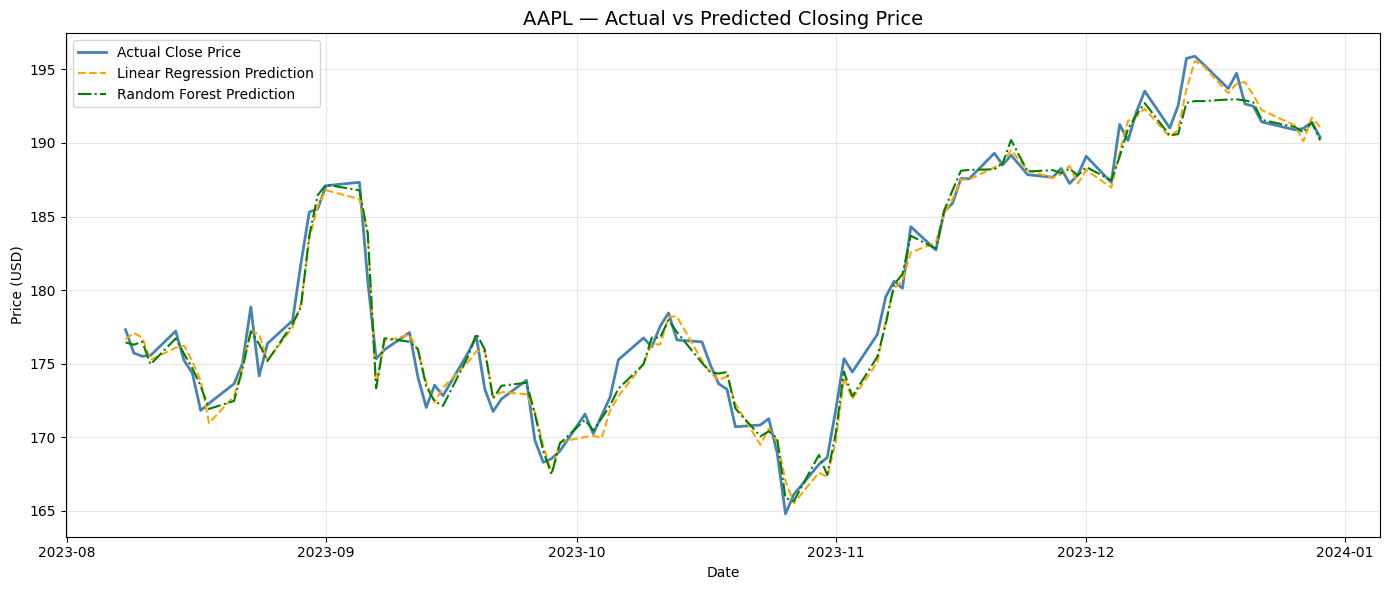

Plot saved!


In [13]:
plt.figure(figsize=(14, 6))

# Get the date index for the test set
test_dates = df.index[-len(y_test):]

plt.plot(test_dates, y_test.values,
         label='Actual Close Price', color='steelblue', linewidth=2)

plt.plot(test_dates, lr_predictions,
         label='Linear Regression Prediction', color='orange',
         linewidth=1.5, linestyle='--')

plt.plot(test_dates, rf_predictions,
         label='Random Forest Prediction', color='green',
         linewidth=1.5, linestyle='-.')

plt.title(f'{ticker} — Actual vs Predicted Closing Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved!")

C:\Program Files\KMSpico\temp\ipykernel_4204\3024362214.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


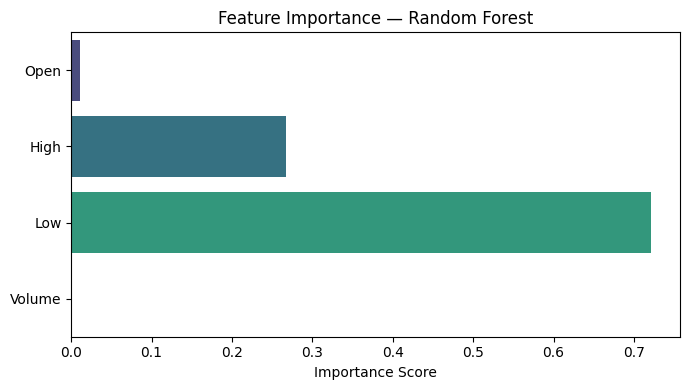

In [14]:
feature_names = ['Open', 'High', 'Low', 'Volume']
importances = rf_model.feature_importances_

plt.figure(figsize=(7, 4))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()